<a href="https://colab.research.google.com/github/kaushalkalas-awesome/DKTE-TY-DL/blob/main/DL_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tensorflow as tf
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing import sequence

max_features = 10000
max_words = 500

(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=max_features)

x_train = sequence.pad_sequences(x_train, maxlen=max_words)
x_test = sequence.pad_sequences(x_test, maxlen=max_words)

x_train, y_train

(array([[   0,    0,    0, ...,   19,  178,   32],
        [   0,    0,    0, ...,   16,  145,   95],
        [   0,    0,    0, ...,    7,  129,  113],
        ...,
        [   0,    0,    0, ...,    4, 3586,    2],
        [   0,    0,    0, ...,   12,    9,   23],
        [   0,    0,    0, ...,  204,  131,    9]], dtype=int32),
 array([1, 0, 0, ..., 0, 1, 0]))

In [ ]:
# implemention of RNN
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense

model = Sequential()
model.add(Embedding(max_features, 32))
model.add(SimpleRNN(32))
model.add(Dense(1, activation='sigmoid'))

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [ ]:
history_RNN = model.fit(x_train, y_train, epochs=5, batch_size=64, validation_data=(x_test, y_test))
test_loss, test_accuracy = model.evaluate(x_test, y_test)

print("Test Accuracy: ", test_accuracy)

Epoch 1/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 20s 45ms/step - accuracy: 0.6351 - loss: 0.6207 - val_accuracy: 0.6796 - val_loss: 0.5854
Epoch 2/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 16s 41ms/step - accuracy: 0.8207 - loss: 0.4084 - val_accuracy: 0.8119 - val_loss: 0.4282
Epoch 3/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 16s 40ms/step - accuracy: 0.8650 - loss: 0.3149 - val_accuracy: 0.8101 - val_loss: 0.4536
Epoch 4/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 16s 40ms/step - accuracy: 0.9394 - loss: 0.1647 - val_accuracy: 0.8136 - val_loss: 0.4995
Epoch 5/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 16s 40ms/step - accuracy: 0.9796 - loss: 0.0703 - val_accuracy: 0.7926 - val_loss: 0.6237
782/782 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.7926 - loss: 0.6237
Test Accuracy:  0.7925999760627747


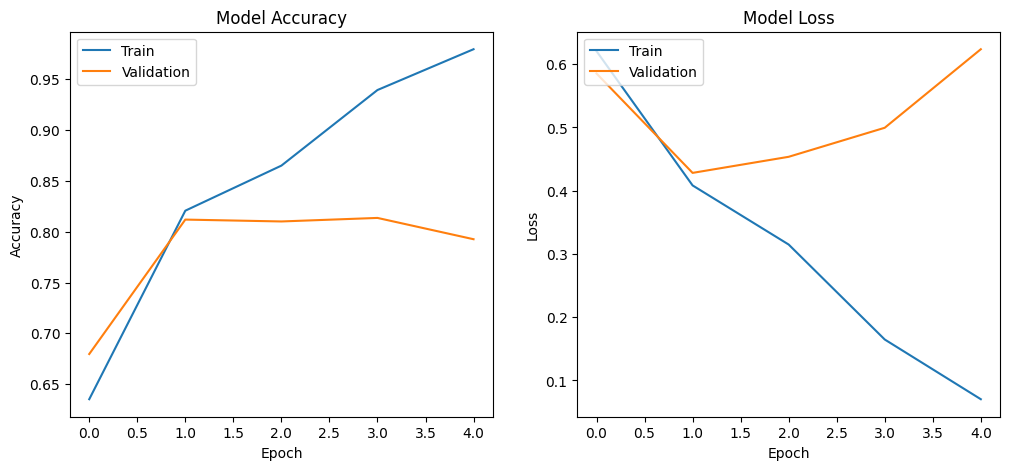

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history_RNN.history['accuracy'])
plt.plot(history_RNN.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.subplot(1, 2, 2)
plt.plot(history_RNN.history['loss'])
plt.plot(history_RNN.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.show()

In [ ]:
# implementation of LSTM
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense

model = Sequential()
model.add(Embedding(max_features, 32))
model.add(LSTM(32))
model.add(Dense(1, activation='sigmoid'))

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [ ]:
history_LSTM = model.fit(x_train, y_train, epochs=5, batch_size=64, validation_data=(x_test, y_test))
test_loss, test_accuracy = model.evaluate(x_test, y_test)

print("Test Accuracy: ", test_accuracy)

Epoch 1/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 12s 28ms/step - accuracy: 0.7809 - loss: 0.4581 - val_accuracy: 0.8604 - val_loss: 0.3394
Epoch 2/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 11s 27ms/step - accuracy: 0.8954 - loss: 0.2666 - val_accuracy: 0.8698 - val_loss: 0.3173
Epoch 3/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 11s 27ms/step - accuracy: 0.9229 - loss: 0.2073 - val_accuracy: 0.8777 - val_loss: 0.3238
Epoch 4/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 11s 28ms/step - accuracy: 0.9342 - loss: 0.1815 - val_accuracy: 0.8695 - val_loss: 0.3399
Epoch 5/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 10s 26ms/step - accuracy: 0.9506 - loss: 0.1380 - val_accuracy: 0.8717 - val_loss: 0.3846
782/782 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.8717 - loss: 0.3846
Test Accuracy:  0.8716800212860107


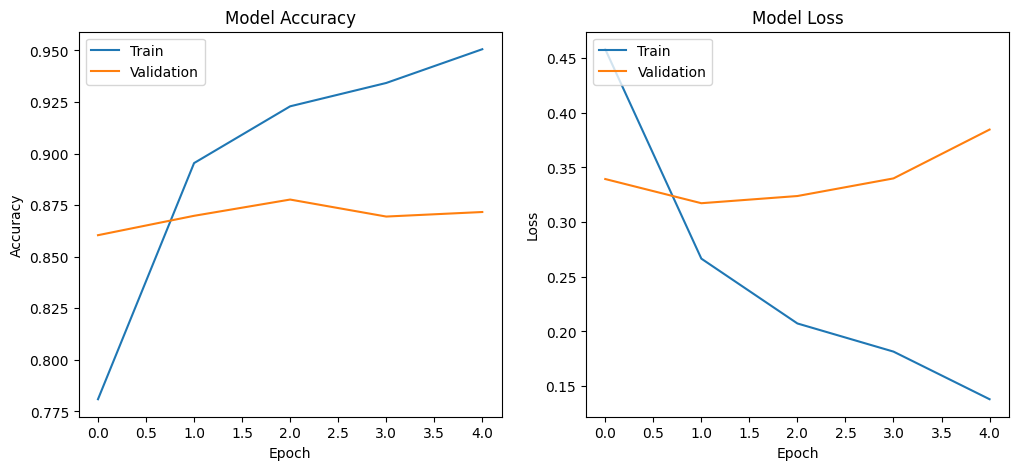

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history_LSTM.history['accuracy'])
plt.plot(history_LSTM.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.subplot(1, 2, 2)
plt.plot(history_LSTM.history['loss'])
plt.plot(history_LSTM.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.show()

In [ ]:
# implementation of GRU
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, GRU, Dense

model = Sequential()
model.add(Embedding(max_features, 32))
model.add(GRU(32))
model.add(Dense(1, activation='sigmoid'))

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [ ]:
history_GRU = model.fit(x_train, y_train, epochs=5, batch_size=64, validation_data=(x_test, y_test))
test_loss, test_accuracy = model.evaluate(x_test, y_test)

print("Test Accuracy: ", test_accuracy)

Epoch 1/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 12s 28ms/step - accuracy: 0.7750 - loss: 0.4533 - val_accuracy: 0.8499 - val_loss: 0.3518
Epoch 2/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 11s 27ms/step - accuracy: 0.8922 - loss: 0.2723 - val_accuracy: 0.8367 - val_loss: 0.3671
Epoch 3/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 11s 27ms/step - accuracy: 0.9224 - loss: 0.2073 - val_accuracy: 0.8678 - val_loss: 0.3299
Epoch 4/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 20s 26ms/step - accuracy: 0.9401 - loss: 0.1661 - val_accuracy: 0.8698 - val_loss: 0.3477
Epoch 5/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 10s 26ms/step - accuracy: 0.9504 - loss: 0.1401 - val_accuracy: 0.8718 - val_loss: 0.3612
782/782 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.8718 - loss: 0.3612
Test Accuracy:  0.8717600107192993


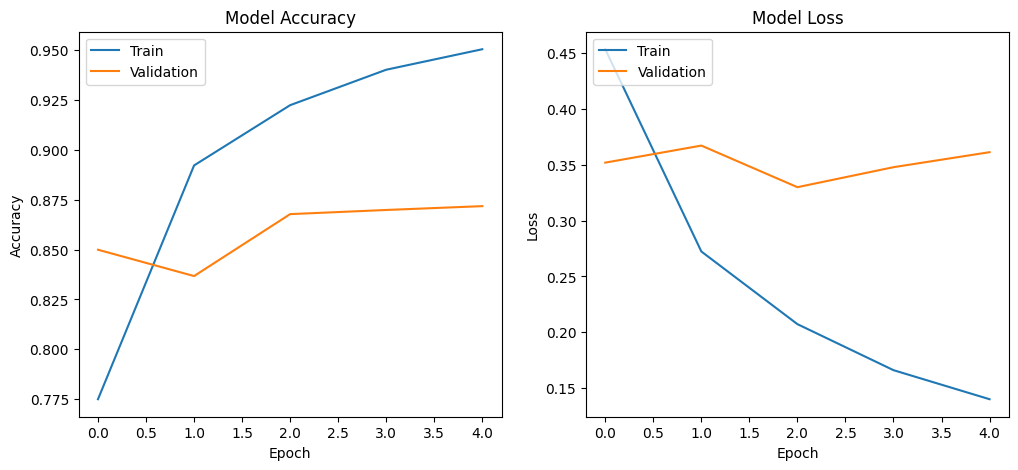

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history_GRU.history['accuracy'])
plt.plot(history_GRU.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.subplot(1, 2, 2)
plt.plot(history_GRU.history['loss'])
plt.plot(history_GRU.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.show()

In [ ]:
import pandas as pd

rnn_metrics = {
    'Model': 'RNN',
    'Train Accuracy': history_RNN.history['accuracy'][-1],
    'Validation Accuracy': history_RNN.history['val_accuracy'][-1],
    'Train Loss': history_RNN.history['loss'][-1],
    'Validation Loss': history_RNN.history['val_loss'][-1]
}

lstm_metrics = {
    'Model': 'LSTM',
    'Train Accuracy': history_LSTM.history['accuracy'][-1],
    'Validation Accuracy': history_LSTM.history['val_accuracy'][-1],
    'Train Loss': history_LSTM.history['loss'][-1],
    'Validation Loss': history_LSTM.history['val_loss'][-1]
}

gru_metrics = {
    'Model': 'GRU',
    'Train Accuracy': history_GRU.history['accuracy'][-1],
    'Validation Accuracy': history_GRU.history['val_accuracy'][-1],
    'Train Loss': history_GRU.history['loss'][-1],
    'Validation Loss': history_GRU.history['val_loss'][-1]
}

summary_df = pd.DataFrame([rnn_metrics, lstm_metrics, gru_metrics])
print(summary_df.to_markdown(index=False))

| Model   |   Train Accuracy |   Validation Accuracy |   Train Loss |   Validation Loss |
|:--------|-----------------:|----------------------:|-------------:|------------------:|
| RNN     |           0.9796 |               0.7926  |    0.0702876 |          0.623746 |
| LSTM    |           0.9506 |               0.87168 |    0.137989  |          0.384601 |
| GRU     |           0.9504 |               0.87176 |    0.140111  |          0.361177 |
